# Setup

In [1]:
import sys
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

# Device configuration
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Version information')

print('python: {}'.format(sys.version))
print('matplotlib: {}'.format(matplotlib.__version__))
print('numpy: {}'.format(np.__version__))

# %load_ext autoreload
# %autoreload 2
# %reload_ext autoreload

## This wraps output text according to the window size
from IPython.display import HTML, display

def set_css():
  display(HTML('''
  <style>
    pre {
        white-space: pre-wrap;
    }
  </style>
  '''))
get_ipython().events.register('pre_run_cell', set_css)

Version information
python: 3.13.1 (v3.13.1:06714517797, Dec  3 2024, 14:00:22) [Clang 15.0.0 (clang-1500.3.9.4)]
matplotlib: 3.10.8
numpy: 2.4.1


# The Dataset

## Fetching the dataset.
We will only fetch several categories of sklearn's 20newsgroups dataset

In [2]:
from sklearn.datasets import fetch_20newsgroups
categories = ['misc.forsale','alt.atheism','comp.graphics', 'sci.med','talk.politics.misc']
train = fetch_20newsgroups(subset='train', categories=categories)
test = fetch_20newsgroups(subset='test', categories=categories)

Error in callback <function set_css at 0x137064ea0> (for pre_run_cell), with arguments args (<ExecutionInfo object at 11023f360, raw_cell="from sklearn.datasets import fetch_20newsgroups
ca.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/sklearn_metric_examples_1.ipynb#W4sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

## Getting Familiar with the Dataset

In [3]:
# Returned Keys
print('Keys returned in the dataset: ', train.keys())
print()

# Number of datapoints in train and test
print('Number of datapoints in train', len(train.data))
print('Number of datapoints in test', len(test.data))
print()

# Get count of datapoints in each category:
# for label in train.
target_i, i_count = np.unique(train.target, return_counts=True)
for target, count in zip(target_i, i_count):
    target_name = train.target_names[target]
    print('Number of datapoints in {}: {}'.format(target_name, count))

Error in callback <function set_css at 0x137064ea0> (for pre_run_cell), with arguments args (<ExecutionInfo object at 137763bf0, raw_cell="# Returned Keys
print('Keys returned in the datase.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/sklearn_metric_examples_1.ipynb#W6sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

Keys returned in the dataset:  dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])

Number of datapoints in train 2708
Number of datapoints in test 1804

Number of datapoints in alt.atheism: 480
Number of datapoints in comp.graphics: 584
Number of datapoints in misc.forsale: 585
Number of datapoints in sci.med: 594
Number of datapoints in talk.politics.misc: 465


In [5]:
# Sample data
indices = [0, 42, 721]
for i in indices:
    print('******SAMPLE DATA AT INDEX {}******:'.format(i))
    print('Sample data target:', train.target[i])
    print('Sample data target_name:', train.target_names[train.target[i]])
    print('Sample data text:')
    print(train.data[i])
    print()

Error in callback <function set_css at 0x137064ea0> (for pre_run_cell), with arguments args (<ExecutionInfo object at 13776f570, raw_cell="# Sample data
indices = [0, 42, 721]
for i in indi.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/sklearn_metric_examples_1.ipynb#X10sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

******SAMPLE DATA AT INDEX 0******:
Sample data target: 2
Sample data target_name: misc.forsale
Sample data text:
From: sponna@eos.ncsu.edu (SRIKANTH  PONNAPALLI)
Subject: Super Scope6 for sale (SNES)
Organization: North Carolina State University
Lines: 17


	Hello folks, I've a super scope 6 for sale, it comes with a 
CRT and all boxes and instructions included $50 shipping included. 
I got that only a month back and used only twice.
-- 
                     ,,,                                ,,,
                    (o o)                              (o o)
         _______oOO__(_)__OOo______________________oOO__(_)__OOo________
        |                               |                               |
        |  Srikanth Ponnapalli          |      E-mail address:          |
        |      PoBox: 5604,             |                               |
        |  Raleigh N.C. 27650-5604      |      sponna@eos.ncsu.edu      |
        |  Phone:(919) 781-5448         |      ponna-s@aza.csc.ncsu

## Vectorizing the dataset using tf-idf

In [6]:
# Import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
vectorizer = TfidfVectorizer()

# Fit the vectorizer using the train data and transform the train data into vectors
vectors_train = vectorizer.fit_transform(train.data)

# Transform the test data using the vectorizer fitted on the train data
vectors_test = vectorizer.transform(test.data)

# Inspect the vector shapes for both test and train
print('Train vectors shape:', vectors_train.shape)
print('Test vectors.shape:', vectors_test.shape)

Error in callback <function set_css at 0x137064ea0> (for pre_run_cell), with arguments args (<ExecutionInfo object at 1377af050, raw_cell="# Import TfidfVectorizer
from sklearn.feature_extr.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/sklearn_metric_examples_1.ipynb#X12sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

Train vectors shape: (2708, 40734)
Test vectors.shape: (1804, 40734)


# Classification Models

## Perceptron with Accuracy Score as metric
Accuracy is the ratio between the number of correctly predicted datapoints against the total number of datapoints.

$$Accuracy = \dfrac{TP + TN}{TP + TN + FP + FN}$$

Where TP = True Positives, TN = True Negatives, FP = False Positives, FN = False Negatives


In [7]:
# Import the classifier and the metric
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

model = 'Perceptron'
metric = 'Accuracy Score'

# Initialize the classifier
clf = Perceptron()

# Fit the classifier using the vectorized data and target labels
clf.fit(vectors_train, train.target)

# Predict the labels of the testing set
pred_test = clf.predict(vectors_test)

# Assess performance of classifier using Accuracy score as the metric
clf_test_score = accuracy_score(test.target, pred_test)
print('{} for {}: {:.4f}'.format(metric, model, clf_test_score))

Error in callback <function set_css at 0x137064ea0> (for pre_run_cell), with arguments args (<ExecutionInfo object at 1377aeb50, raw_cell="# Import the classifier and the metric
from sklear.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/sklearn_metric_examples_1.ipynb#X15sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

Accuracy Score for Perceptron: 0.9157


## SVM (with linear kernel) with Recall Score as metric
Recall is the same the True Positive Rate (TPR), out of the total number of positive samples what percentage is correctly predicted as positive.

$$Recall = \dfrac{TP}{TP + FN}$$

In multiclass classification, the scores are calculated separately per class. Out of all of the datapoints in class 0, what is the percentage of correctly predicted datapoints in class 0. Repeat this calculation for each class. The sklearn recall_score function allows the score to be returned separately for each class or as an average.

In [8]:
# Import the classifier and the metric
from sklearn.svm import SVC
from sklearn.metrics import recall_score

model = 'SVM with linear kernel'
metric = 'Recall Score (averaged and unweighted)'
metric2 = 'Recall Score (not averaged)'

# Initialize the classifier
clf = SVC(kernel='linear')

# Fit the classifier using the vectorized data and target labels
clf.fit(vectors_train, train.target)

# Predict the labels of the testing set
pred_test = clf.predict(vectors_test)

# Assess performance of classifier using Recall score as the metric
# Set average='macro' for an unweighted average
clf_test_score = recall_score(test.target, pred_test, average='macro')
print('{} for {}: {:.4f}'.format(metric, model, clf_test_score))

# Assess performance of classifier using Recall score as the metric
# Set average=None for no averaging and a list of scores per class
clf_test_score = recall_score(test.target, pred_test, average=None)
print('{} for {}: '.format(metric2, model), clf_test_score)

Error in callback <function set_css at 0x137064ea0> (for pre_run_cell), with arguments args (<ExecutionInfo object at 137d3f890, raw_cell="# Import the classifier and the metric
from sklear.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/sklearn_metric_examples_1.ipynb#X20sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

Recall Score (averaged and unweighted) for SVM with linear kernel: 0.9249
Recall Score (not averaged) for SVM with linear kernel:  [0.92163009 0.94858612 0.97179487 0.88888889 0.89354839]


## SVM (with rbf kernel) with Precision Score as metric
Precision is a measure of the classifier's ability to not label negative samples as positive. Out of the total number of predicted positive samples what percentage is actually labeled as positive.

$$Precision = \dfrac{TP}{TP + FP}$$

In multiclass classification, the scores are calculated separately per class. Out of all of the datapoints predicted to be in class 0, what is the percentage of the predicted datapoints that correctly belong in class 0. Repeat this calculation for each class. The sklearn precision_score function allows the score to be returned separately for each class or as an average.

In [9]:
# Import the classifier and the metric
from sklearn.svm import SVC
from sklearn.metrics import precision_score

model = 'SVM with rbf kernel'
metric = 'Precision Score (averaged and unweighted)'
metric2 = 'Precision Score (not averaged)'

# Initialize the classifier
clf = SVC(kernel='rbf')

# Fit the classifier using the vectorized data and target labels
clf.fit(vectors_train, train.target)

# Predict the labels of the testing set
pred_test = clf.predict(vectors_test)

# Assess performance of classifier using Precision score as the metric
# Set average='macro' for an unweighted average
clf_test_score = precision_score(test.target, pred_test, average='macro')
print('{} for {}: {:.4f}'.format(metric, model, clf_test_score))

# Assess performance of classifier using Precision score as the metric
# Set average=None for no averaging and a list of scores per class
clf_test_score = precision_score(test.target, pred_test, average=None)
print('{} for {}: '.format(metric2, model), clf_test_score)

Error in callback <function set_css at 0x137064ea0> (for pre_run_cell), with arguments args (<ExecutionInfo object at 137d3f7a0, raw_cell="# Import the classifier and the metric
from sklear.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/sklearn_metric_examples_1.ipynb#X22sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

Precision Score (averaged and unweighted) for SVM with rbf kernel: 0.9084
Precision Score (not averaged) for SVM with rbf kernel:  [0.95932203 0.85348837 0.88578089 0.89095745 0.95255474]


## Multinomial Naive Bayes with F1 score as metric
F1 Score is the harmonic mean of Precision and Recall.
$$F1 \: score = \dfrac{2}{\frac{1}{Precision} + \frac{1}{Recall}} = \dfrac{2 * (Precision * Recall)}{Precision + Recall}$$
With Precision and Recall defined in the above examples

In [10]:
# Import the classifier and the metric
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score

model = 'Multinomial Naive Bayes'
metric = 'F1 Score (averaged and unweighted)'
metric2 = 'F1 Score (not averaged)'

# Initialize the classifier
clf = MultinomialNB(alpha=0.1)

# Fit the classifier using the vectorized data and target labels
clf.fit(vectors_train, train.target)

# Predict the labels of the testing set
pred_test = clf.predict(vectors_test)

# Assess performance of classifier using F1 score as the metric
# Set average='macro' for an unweighted average
clf_test_score = f1_score(test.target, pred_test, average='macro')
print('{} for {}: {:.4f}'.format(metric, model, clf_test_score))

# Assess performance of classifier using F1 score as the metric
# Set average=None for no averaging and a list of scores per class
clf_test_score = f1_score(test.target, pred_test, average=None)
print('{} for {}: '.format(metric2, model), clf_test_score)

Error in callback <function set_css at 0x137064ea0> (for pre_run_cell), with arguments args (<ExecutionInfo object at 137cab5b0, raw_cell="# Import the classifier and the metric
from sklear.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/sklearn_metric_examples_1.ipynb#X24sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

F1 Score (averaged and unweighted) for Multinomial Naive Bayes: 0.9266
F1 Score (not averaged) for Multinomial Naive Bayes:  [0.93146417 0.93213828 0.94709677 0.91898734 0.90322581]


## Logistic Regression with ROC AUC Score as metric and Confusion Matrix Plot
Compute Area Under the Receiver Operating Characteristic Curve (ROC AUC)

Confusion Matrix is a visual way of determining the prediction performance of your model per class. The x and y axis are labeled using the prediction classes. The diagonal values represent the number of datapoints that were predicted correctly for each class. In a row, the values not in the matrix diagonal represent the number of datapoints in one class that are misclassified as other labels. In a column, the values not in the matrix diagonal represent the number of other classes misclassified into a specific class.

In [14]:
# Import the classifier and the metric
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

model = 'Logistic Regression'
metric = 'ROC AUC Score'

# Initialize the classifier
clf = LogisticRegression()

# Fit the classifier using the vectorized data and target labels
clf.fit(vectors_train, train.target)

# Predict the labels of the testing set
pred_proba_test = clf.predict_proba(vectors_test)
pred_test = clf.predict(vectors_test)

# Assess performance of classifier using Precision score as the metric
# Set multi_class='ovr' for One-vs-rest
clf_test_score = roc_auc_score(test.target, pred_proba_test, multi_class='ovr')
print('{} for {}: {:.4f}'.format(metric, model, clf_test_score))

Error in callback <function set_css at 0x137064ea0> (for pre_run_cell), with arguments args (<ExecutionInfo object at 15811a810, raw_cell="# Import the classifier and the metric
from sklear.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/sklearn_metric_examples_1.ipynb#X26sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

ROC AUC Score for Logistic Regression: 0.9873


Error in callback <function set_css at 0x137064ea0> (for pre_run_cell), with arguments args (<ExecutionInfo object at 1377d9cc0, raw_cell="# Import the classifier and the metric
import seab.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/sklearn_metric_examples_1.ipynb#X30sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

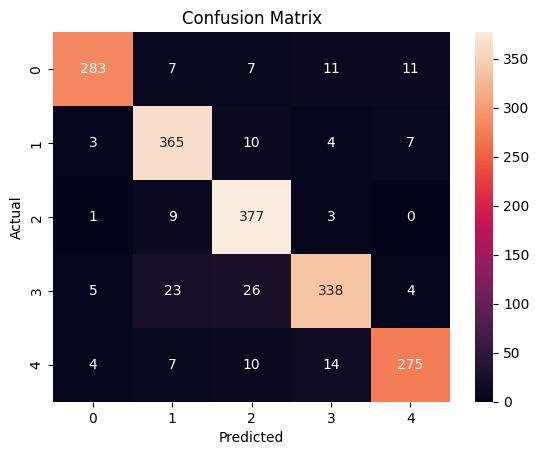

In [12]:
# Import the classifier and the metric
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Plotting a confusion matrix using seaborn:

# Get confusion matrix counts
cm = confusion_matrix(test.target, pred_test)

# Pass confusion matrix output into heatmap
ax = sns.heatmap(cm, annot=True, fmt='d')

# Create Title and Axes Labels
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show actual plot
plt.show()

## Two Layer Neural Network with Accuracy as metric

Create and compile the model

In [17]:
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import OneHotEncoder

# define the model
model = Sequential()
model.add(Dense(500, input_dim=vectors_train.shape[1], activation='relu'))
model.add(Dense(len(train['target_names']), activation='softmax'))

# compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

Error in callback <function set_css at 0x137064ea0> (for pre_run_cell), with arguments args (<ExecutionInfo object at 15a250cd0, raw_cell="import keras
from tensorflow.keras.models import S.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/sklearn_metric_examples_1.ipynb#X33sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

/Users/willbrennan/Desktop/Coding/school_repo/school_code/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Convert the data to array form and the labels to one hot encoded vectors. Train the model and then evaluate the model.

In [18]:
# convert features into array from sparse matrix
X_train = vectors_train.toarray()
X_test = vectors_test.toarray()

# convert labels to one hot encoded format
oh = OneHotEncoder()
y_train = oh.fit_transform((train.target).reshape(-1,1)).toarray()
y_test = oh.transform((test.target).reshape(-1,1)).toarray()

# train the model
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size = 128,
    shuffle = True,
    validation_data=(X_test, y_test))

# evaluate the model
score = model.evaluate(X_test, y_test, batch_size=128)
pred_test = model.predict(X_test).argmax(axis = 1)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Error in callback <function set_css at 0x137064ea0> (for pre_run_cell), with arguments args (<ExecutionInfo object at 175714050, raw_cell="# convert features into array from sparse matrix
X.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/sklearn_metric_examples_1.ipynb#X35sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.8501 - loss: 1.3093 - val_accuracy: 0.9213 - val_loss: 0.9602
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9926 - loss: 0.4551 - val_accuracy: 0.9274 - val_loss: 0.4807
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9974 - loss: 0.1180 - val_accuracy: 0.9329 - val_loss: 0.3329
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9993 - loss: 0.0451 - val_accuracy: 0.9324 - val_loss: 0.2865
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9996 - loss: 0.0243 - val_accuracy: 0.9307 - val_loss: 0.2650
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9307 - loss: 0.2650
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Test loss: 0.2650279998779297
Test accuracy: 0.9307095408439636


We can now print out accuracy and loss curves using the history data from our training.

Error in callback <function set_css at 0x137064ea0> (for pre_run_cell), with arguments args (<ExecutionInfo object at 175707380, raw_cell="# list all data in history
print(history.history.k.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/sklearn_metric_examples_1.ipynb#X40sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


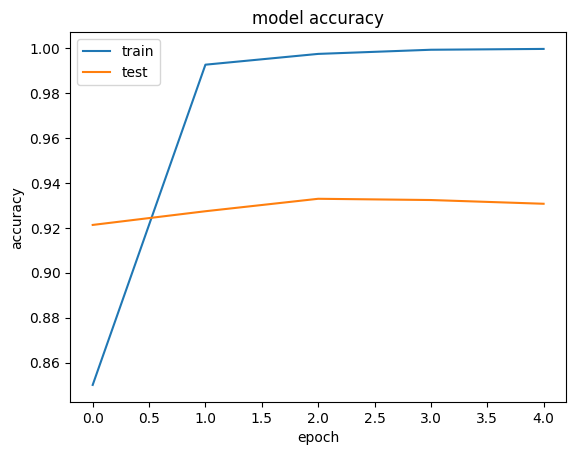

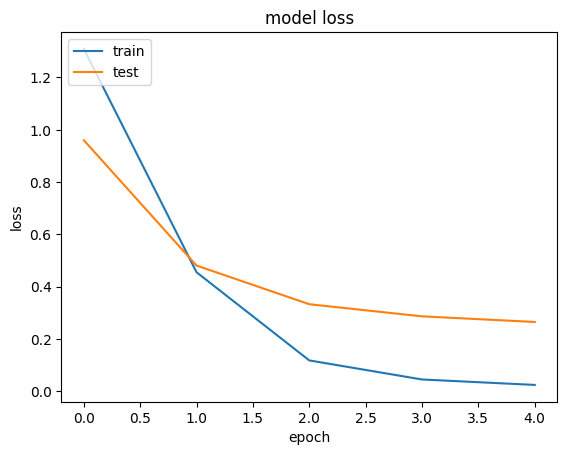

In [19]:
# list all data in history
print(history.history.keys())

# summarize history for accuracy and loss
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

We can also print out a confusion matrix using the predicted labels of the X_test dataset.

Error in callback <function set_css at 0x137064ea0> (for pre_run_cell), with arguments args (<ExecutionInfo object at 17598d9d0, raw_cell="# Import the classifier and the metric
import seab.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/sklearn_metric_examples_1.ipynb#X42sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

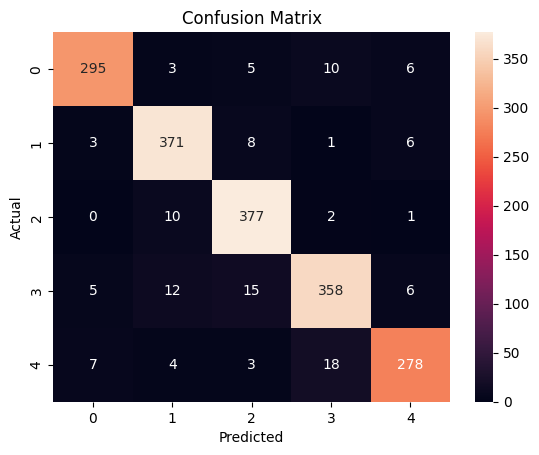

0: misc.forsale
1: alt.atheism
2: comp.graphics
3: sci.med
4: talk.politics.misc


In [20]:
# Import the classifier and the metric
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Plotting a confusion matrix using seaborn:

# Get confusion matrix counts
cm = confusion_matrix(test.target, pred_test)

# Pass confusion matrix output into heatmap
ax = sns.heatmap(cm, annot=True, fmt='d')

# Create Title and Axes Labels
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show actual plot
plt.show()

# legend
for idx, cat in enumerate(categories):
    print(f'{idx}: {cat}')